# Part 3 — Regularization Study with Locked Adam

## Purpose and hypothesis

**H3-REG.** With standard Adam fixed, explicit regularization should move Macro-F1, balanced accuracy, and minority-class recall more than it moves raw accuracy. Moderate dropout or L2 should reduce train–validation gaps; label smoothing and modest input noise may improve seed stability. Over-regularization is expected to hurt rare-class precision or recall.

The optimizer, batch size, data, split, scaling, and Linear/ReLU backbone are fixed. Only the permitted regularization mechanisms change.

In [1]:
from pathlib import Path
from copy import deepcopy
import os, math, platform, random, time, json, warnings
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# reproducibility and run modes
BASE_SEED = 42
FULL_SEEDS = [42, 202, 7641]
SMOKE_TEST = os.getenv("OL_SMOKE_TEST", "0") == "1"
QUICK_MODE = os.getenv("OL_QUICK_MODE", "0") == "1" or SMOKE_TEST
SEEDS = [42] if QUICK_MODE else FULL_SEEDS
DEVICE = torch.device(os.getenv("OL_DEVICE", "cpu"))
TORCH_THREADS = max(1, min(4, os.cpu_count() or 1))
torch.set_num_threads(TORCH_THREADS)

def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

set_all_seeds(BASE_SEED)

# input directories
DATA_PATH = Path("output_data/eda_dataset_original/dataset_stratified.csv")
DATA_PATH_TEST = Path("output_data/eda_dataset_original/dataset_remainder.csv")
RAW_DATA_PATH = Path("dataset_covertype/covtype.data")
TARGET_COL = "Cover_Type"

# Values are fixed by the SL Report notebook.
SL_ARCHITECTURE = (64, 64)
SL_LEARNING_RATE = 0.10
SL_BATCH_SIZE = 512
SL_WEIGHT_DECAY = 1e-4
SL_MAX_EPOCHS = 70
SL_PATIENCE = 10

# Exact SL-notebook reference result from the output.
SL_REFERENCE = {
    "method": "SL PyTorch SGD-only reference",
    "architecture": str(SL_ARCHITECTURE),
    "parameter_count": 8135,
    "learning_rate": 0.10,
    "batch_size": 512,
    "weight_decay": 1e-4,
    "best_epoch": 26,
    "epochs_run": 36,
    "test_accuracy": 0.6400986075,
    "test_macro_f1": 0.5526402660,
    "test_balanced_accuracy": 0.7019769460,
    "fit_time_sec_on_original_hardware": 2.675669709,
}

### 1. Data loading: Exact SL report split and processing

In [2]:
df_source = pd.read_csv(DATA_PATH)
df_test_external = pd.read_csv(DATA_PATH_TEST)

assert TARGET_COL in df_source.columns and TARGET_COL in df_test_external.columns
feature_cols = [c for c in df_source.columns if c != TARGET_COL]
assert len(feature_cols) == 54, f"Expected 54 features, found {len(feature_cols)}"
assert list(df_test_external.columns) == list(df_source.columns), "Development/test columns differ."
assert len(df_source) == 20_000, f"Expected 20,000 sampled rows, found {len(df_source)}"
assert len(df_test_external) == 561_012, f"Expected 561,012 remainder rows, found {len(df_test_external)}"
assert df_source.isna().sum().sum() == 0 and df_test_external.isna().sum().sum() == 0

X_source_df = df_source[feature_cols].copy()
y_source_raw = df_source[TARGET_COL].copy()
X_test_df = df_test_external[feature_cols].copy()
y_test_raw = df_test_external[TARGET_COL].copy()

### 2. Reproducing the SL-report notebook stable class mapping

In [3]:
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_source_raw, y_test_raw], ignore_index=True))
class_labels = label_encoder.classes_
classes = np.arange(len(class_labels))
class_names = [f"Cover_Type_{c}" for c in class_labels]

X_train_df, X_val_df, y_train_raw, y_val_raw = train_test_split(
    X_source_df,
    y_source_raw,
    test_size=0.20,
    stratify=y_source_raw,
    random_state=BASE_SEED,
)

y_train = label_encoder.transform(y_train_raw).astype(np.int64)
y_val = label_encoder.transform(y_val_raw).astype(np.int64)
y_test = label_encoder.transform(y_test_raw).astype(np.int64)

### 3. Leakage safety: fittin learned scalling only on 16K rows training split

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

class_weights_np = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
).astype(np.float32)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

steps_per_epoch = math.ceil(len(y_train) / SL_BATCH_SIZE)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source": [DATA_PATH.name, DATA_PATH.name, DATA_PATH_TEST.name],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "purpose": ["fit", "selection only", "final locked evaluation only"],
})
display(split_summary)

print({
    "device": str(DEVICE),
    "torch": torch.__version__,
    "python": platform.python_version(),
    "cpu": platform.processor() or platform.machine(),
    "torch_threads": TORCH_THREADS,
    "quick_mode": QUICK_MODE,
    "seeds": SEEDS,
    "steps_per_epoch": steps_per_epoch,
})


,split,source,rows,purpose
0,train,dataset_stratified.csv,16000,fit
1,validation,dataset_stratified.csv,4000,selection only
2,test,dataset_remainder.csv,561012,final locked evaluation only


{'device': 'cpu', 'torch': '2.5.1', 'python': '3.11.15', 'cpu': 'x86_64', 'torch_threads': 4, 'quick_mode': False, 'seeds': [42, 202, 7641], 'steps_per_epoch': 32}


### 4. Fixing PyTorch backbone with permitted dropout regularizaiton

In [5]:
class CompactMLP(nn.Module):
    """The exact 54 -> 64 -> 64 -> 7 SL backbone.

    Dropout modules are inserted only when Part 3/4 explicitly studies regularization;
    all Linear layer dimensions and ReLU placements remain unchanged.
    """
    def __init__(self, input_dim=54, hidden_layers=SL_ARCHITECTURE, output_dim=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self.dropout = float(dropout)

    def forward(self, x):
        return self.net(x)


def count_parameters(model, trainable_only=True):
    params = (p for p in model.parameters() if (p.requires_grad or not trainable_only))
    return sum(p.numel() for p in params)


_base_model_check = CompactMLP().to(DEVICE)
assert count_parameters(_base_model_check) == 8135
print(f"Backbone parameter count confirmed: {count_parameters(_base_model_check):,}")
del _base_model_check

Backbone parameter count confirmed: 8,135


### 5. Metrics and Evaluation

In [6]:
def metric_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }


def make_criterion(label_smoothing=0.0):
    return nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=float(label_smoothing))


def evaluate_tensor(model, X_t, y_t, criterion):
    model.eval()
    with torch.inference_mode():
        logits = model(X_t)
        loss = float(criterion(logits, y_t).item())
        pred = logits.argmax(dim=1).cpu().numpy()
    out = metric_dict(y_t.cpu().numpy(), pred)
    out["loss"] = loss
    return out, pred


def full_report(y_true, y_pred):
    report = pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, target_names=class_names,
        output_dict=True, zero_division=0,
    )).T
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=classes),
        index=class_names, columns=class_names,
    )
    return report, cm


def clone_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})

### 6. Adam without bias correction

In [7]:
class AdamNoBiasCorrection(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        if lr <= 0:
            raise ValueError("lr must be positive")
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if g.is_sparse:
                    raise RuntimeError("Sparse gradients are not supported.")
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                state["step"] += 1
                m, v = state["exp_avg"], state["exp_avg_sq"]
                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)
                p.addcdiv_(m, v.sqrt().add_(group["eps"]), value=-group["lr"])
        return loss


def build_optimizer(name, model, lr, beta1=0.9, beta2=0.999, weight_decay=0.0):
    params = [p for p in model.parameters() if p.requires_grad]
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.0, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=False, weight_decay=weight_decay)
    if name == "sgd_nesterov":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    if name == "adam_no_bias_correction":
        return AdamNoBiasCorrection(params, lr=lr, betas=(beta1, beta2))
    if name == "adam_beta1_zero":
        return torch.optim.Adam(params, lr=lr, betas=(0.0, beta2), weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")

### 7. Controlled-budget trainer

In [8]:
@dataclass
class TrainConfig:
    optimizer_name: str
    lr: float
    max_updates: int
    batch_size: int = SL_BATCH_SIZE
    beta1: float = 0.9
    beta2: float = 0.999
    weight_decay: float = 0.0
    dropout: float = 0.0
    label_smoothing: float = 0.0
    input_noise_std: float = 0.0
    early_stopping_patience: int | None = None
    selection_metric: str = "val_loss"
    restore_best: bool = True
    eval_every_updates: int = steps_per_epoch


def train_controlled(config: TrainConfig, seed: int, initial_state=None):
    set_all_seeds(seed)
    model = CompactMLP(dropout=config.dropout).to(DEVICE)
    if initial_state is not None:
        load_state(model, initial_state)
    criterion = make_criterion(config.label_smoothing)
    optimizer = build_optimizer(
        config.optimizer_name, model, config.lr, config.beta1, config.beta2, config.weight_decay
    )

    n = len(y_train)
    update = 0
    history = []
    start_time = time.perf_counter()
    best_score = np.inf if config.selection_metric == "val_loss" else -np.inf
    best_state = clone_state(model)
    best_update = 0
    stale_evals = 0
    stopped_early = False
    interval_loss_sum = 0.0
    interval_examples = 0

    while update < config.max_updates:
        model.train()
        permutation = torch.randperm(n, device=DEVICE)
        for batch_start in range(0, n, config.batch_size):
            if update >= config.max_updates:
                break
            idx = permutation[batch_start: batch_start + config.batch_size]
            xb = X_train_t[idx]
            if config.input_noise_std > 0:
                xb = xb + torch.randn_like(xb) * config.input_noise_std
            yb = y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            update += 1
            interval_loss_sum += float(loss.item()) * len(idx)
            interval_examples += len(idx)

            should_eval = (
                update == 1
                or update % config.eval_every_updates == 0
                or update == config.max_updates
            )
            if not should_eval:
                continue

            train_metrics, _ = evaluate_tensor(model, X_train_t, y_train_t, criterion)
            val_metrics, _ = evaluate_tensor(model, X_val_t, y_val_t, criterion)
            elapsed = time.perf_counter() - start_time
            row = {
                "seed": seed,
                "update": update,
                "gradient_evaluations": update,
                "optimizer_updates": update,
                "examples_seen": update * config.batch_size,
                "wall_time_sec": elapsed,
                "interval_train_loss": interval_loss_sum / max(1, interval_examples),
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
            }
            history.append(row)
            interval_loss_sum = 0.0
            interval_examples = 0

            score = val_metrics[config.selection_metric.replace("val_", "")]
            improved = score < best_score - 1e-6 if config.selection_metric == "val_loss" else score > best_score + 1e-6
            if improved:
                best_score = score
                best_state = clone_state(model)
                best_update = update
                stale_evals = 0
            else:
                stale_evals += 1

            if config.early_stopping_patience is not None and stale_evals >= config.early_stopping_patience:
                stopped_early = True
                break
        if stopped_early:
            break

    total_time = time.perf_counter() - start_time
    final_state = clone_state(model)
    if config.restore_best:
        load_state(model, best_state)
    selected_metrics, selected_pred = evaluate_tensor(model, X_val_t, y_val_t, criterion)

    return {
        "model": model,
        "config": asdict(config),
        "seed": seed,
        "history": pd.DataFrame(history),
        "best_state": best_state,
        "final_state": final_state,
        "best_update": int(best_update),
        "updates_run": int(update),
        "gradient_evaluations": int(update),
        "wall_time_sec": float(total_time),
        "stopped_early": stopped_early,
        "selected_val_metrics": selected_metrics,
        "selected_val_pred": selected_pred,
        "parameter_count": count_parameters(model),
    }


def evaluate_test_locked(run, method_name):
    """Call only after all validation-based choices have been locked."""
    criterion = make_criterion(run["config"].get("label_smoothing", 0.0))
    metrics, pred = evaluate_tensor(run["model"], X_test_t, y_test_t, criterion)
    report, cm = full_report(y_test, pred)
    row = {
        "method": method_name,
        "seed": run["seed"],
        "best_val_loss": run["selected_val_metrics"]["loss"],
        "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "wall_time_sec": run["wall_time_sec"],
        "gradient_evaluations": run["gradient_evaluations"],
        "function_evaluations": 0,
        "notes": json.dumps(run["config"], sort_keys=True),
    }
    return row, report, cm, pred


def representative_seed(summary_df, metric="best_val_macro_f1"):
    med = summary_df[metric].median()
    idx = (summary_df[metric] - med).abs().idxmin()
    return int(summary_df.loc[idx, "seed"])


def save_json(path, obj):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, sort_keys=True)


def plot_confusion_matrix(cm_df, title, path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_df.values, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(range(len(class_labels)), class_labels)
    ax.set_yticks(range(len(class_labels)), class_labels)
    fig.colorbar(im, ax=ax)
    threshold = cm_df.values.max() * 0.55
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, str(cm_df.iat[i, j]), ha="center", va="center",
                    fontsize=7, color="white" if cm_df.iat[i, j] > threshold else "black")
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

### 8. Load the validation-selected standard Adam configuration from Part 2

In [9]:
PART = "ol_part3"
FIG_DIR = Path("output_figures") / PART
RESULTS_DIR = Path("output_results") / PART
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

part2_config_path = Path("output_results/ol_part2/best_adam_config.json")
if part2_config_path.exists():
    BEST_ADAM = json.loads(part2_config_path.read_text())
    print("Loaded Part 2 Adam configuration:", BEST_ADAM)
else:
    BEST_ADAM = {"optimizer_name": "adam", "lr": 1e-3, "beta1": 0.9, "beta2": 0.999,
                 "batch_size": SL_BATCH_SIZE, "main_update_budget": 1600}
    print("Part 2 outputs not found; using documented fallback:", BEST_ADAM)

TUNE_UPDATES = 96 if QUICK_MODE else 960
MAIN_UPDATES = 160 if QUICK_MODE else int(BEST_ADAM.get("main_update_budget", 1600))
ADAM_LR = float(BEST_ADAM["lr"])
ADAM_BETA1 = float(BEST_ADAM["beta1"])
ADAM_BETA2 = float(BEST_ADAM["beta2"])

Loaded Part 2 Adam configuration: {'batch_size': 512, 'beta1': 0.9, 'beta2': 0.99, 'lr': 0.003, 'main_update_budget': 1600, 'optimizer_name': 'adam', 'selection_rule': 'coarse validation heatmaps; lowest validation loss with Macro-F1 tie-break'}


### 9. Targeted validation-only sweeps for each regularizer

In [10]:
SWEEPS = {
    "L2 weight decay": [1e-5, 1e-4, 1e-3],
    "Dropout": [0.10, 0.20, 0.30],
    "Label smoothing": [0.05, 0.10],
    "Input noise": [0.01, 0.03],  # standardized-feature units, training only
    "Early stopping": [3, 5, 8],  # validation evaluations of patience
}


def config_for_regularizer(kind, value, max_updates=TUNE_UPDATES):
    kwargs = {}
    if kind == "L2 weight decay": kwargs["weight_decay"] = float(value)
    elif kind == "Dropout": kwargs["dropout"] = float(value)
    elif kind == "Label smoothing": kwargs["label_smoothing"] = float(value)
    elif kind == "Input noise": kwargs["input_noise_std"] = float(value)
    elif kind == "Early stopping": kwargs["early_stopping_patience"] = int(value)
    else: raise ValueError(kind)
    return TrainConfig(
        optimizer_name="adam", lr=ADAM_LR, max_updates=max_updates,
        beta1=ADAM_BETA1, beta2=ADAM_BETA2,
        selection_metric="val_loss", restore_best=True, **kwargs,
    )

sweep_rows = []
for kind, values in SWEEPS.items():
    for value in values:
        run = train_controlled(config_for_regularizer(kind, value), BASE_SEED)
        h = run["history"]
        sweep_rows.append({
            "regularizer": kind, "value": value,
            "best_val_loss": run["selected_val_metrics"]["loss"],
            "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
            "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
            "updates_run": run["updates_run"], "wall_time_sec": run["wall_time_sec"],
            "final_train_val_loss_gap": float(h.iloc[-1].val_loss - h.iloc[-1].train_loss),
        })
regularizer_sweep = pd.DataFrame(sweep_rows)
regularizer_sweep.to_csv(RESULTS_DIR / "regularizer_value_sweeps.csv", index=False)
display(regularizer_sweep)

best_value_by_kind = (
    regularizer_sweep.sort_values(["regularizer", "best_val_macro_f1", "best_val_loss"], ascending=[True, False, True])
    .groupby("regularizer", as_index=False).first()
)
display(best_value_by_kind)
BEST_VALUE = dict(zip(best_value_by_kind.regularizer, best_value_by_kind.value))

,regularizer,value,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy,updates_run,wall_time_sec,final_train_val_loss_gap
0,L2 weight decay,0.00001,0.608824,0.561289,0.745641,960,1.640010,0.246228
1,L2 weight decay,0.00010,0.595441,0.602377,0.777944,960,1.614709,0.210483
2,L2 weight decay,0.00100,0.579777,0.577537,0.769451,960,1.657113,0.172913
3,Dropout,0.10000,0.578606,0.555251,0.759257,960,1.924444,0.122063
4,Dropout,0.20000,0.588785,0.532519,0.751431,960,1.653992,0.096765
5,Dropout,0.30000,0.609019,0.522800,0.742146,960,1.636960,0.093872
6,Label smoothing,0.05000,1.494955,0.446237,0.708846,960,1.679714,0.113926
7,Label smoothing,0.10000,2.104174,0.312032,0.578466,960,2.193891,0.092665
8,Input noise,0.01000,0.589164,0.588247,0.779025,960,2.320234,0.200668
9,Input noise,0.03000,0.598424,0.572053,0.767149,960,2.675480,0.213261


,regularizer,value,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy,updates_run,wall_time_sec,final_train_val_loss_gap
0,Dropout,0.1000,0.578606,0.555251,0.759257,960,1.924444,0.122063
1,Early stopping,3.0000,0.599047,0.566645,0.752769,704,1.941223,0.157432
2,Input noise,0.0100,0.589164,0.588247,0.779025,960,2.320234,0.200668
3,L2 weight decay,0.0001,0.595441,0.602377,0.777944,960,1.614709,0.210483
4,Label smoothing,0.0500,1.494955,0.446237,0.708846,960,1.679714,0.113926


### 10. Confirm each best single regularizer across seeds

In [11]:
single_conditions = {"Adam baseline": TrainConfig(
    "adam", ADAM_LR, MAIN_UPDATES, beta1=ADAM_BETA1, beta2=ADAM_BETA2,
    selection_metric="val_loss", restore_best=True,
)}
for kind, value in BEST_VALUE.items():
    single_conditions[kind] = config_for_regularizer(kind, value, MAIN_UPDATES)

single_runs, single_rows, single_histories = {}, [], []
for label, cfg in single_conditions.items():
    for seed in SEEDS:
        run = train_controlled(cfg, seed)
        single_runs[(label, seed)] = run
        h = run["history"].copy(); h["condition"] = label; single_histories.append(h)
        single_rows.append({
            "condition": label, "seed": seed,
            "best_val_loss": run["selected_val_metrics"]["loss"],
            "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
            "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
            "updates_run": run["updates_run"], "wall_time_sec": run["wall_time_sec"],
            "train_val_loss_gap": float(h.iloc[-1].val_loss - h.iloc[-1].train_loss),
            "stopped_early": run["stopped_early"],
        })
single_summary = pd.DataFrame(single_rows)
single_history = pd.concat(single_histories, ignore_index=True)
single_summary.to_csv(RESULTS_DIR / "single_regularizer_seed_summary.csv", index=False)
display(single_summary)

single_ranking = single_summary.groupby("condition").agg(
    median_val_macro_f1=("best_val_macro_f1", "median"),
    median_val_loss=("best_val_loss", "median"),
    median_val_balanced_accuracy=("best_val_balanced_accuracy", "median"),
    iqr_val_macro_f1=("best_val_macro_f1", lambda x: x.quantile(.75)-x.quantile(.25)),
    median_gap=("train_val_loss_gap", "median"),
    median_updates=("updates_run", "median"),
).reset_index().sort_values(["median_val_macro_f1", "median_val_loss"], ascending=[False, True])
# Exclude baseline when naming the best single regularizer.
best_single = single_ranking[~single_ranking.condition.eq("Adam baseline")].iloc[0].condition
display(single_ranking)
print("Locked best single regularizer:", best_single, "value=", BEST_VALUE[best_single])

,condition,seed,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy,updates_run,wall_time_sec,train_val_loss_gap,stopped_early
0,Adam baseline,42,0.599047,0.566645,0.752769,1600,4.621267,0.298445,False
1,Adam baseline,202,0.599413,0.569909,0.768872,1600,4.332321,0.361751,False
2,Adam baseline,7641,0.591239,0.564122,0.757276,1600,4.249198,0.409857,False
3,Dropout,42,0.578606,0.555251,0.759257,1600,4.884077,0.242363,False
4,Dropout,202,0.611152,0.517743,0.738115,1600,4.800456,0.275497,False
5,Dropout,7641,0.577636,0.558765,0.773043,1600,4.805853,0.220923,False
6,Early stopping,42,0.599047,0.566645,0.752769,704,1.924302,0.157432,True
7,Early stopping,202,0.629576,0.529542,0.725394,512,1.389293,0.122017,True
8,Early stopping,7641,0.592474,0.557303,0.753184,640,1.733251,0.134438,True
9,Input noise,42,0.589164,0.588247,0.779025,1600,4.742529,0.345450,False


,condition,median_val_macro_f1,median_val_loss,median_val_balanced_accuracy,iqr_val_macro_f1,median_gap,median_updates
4,L2 weight decay,0.573778,0.593462,0.757570,0.025036,0.352408,1600.0
0,Adam baseline,0.566645,0.599047,0.757276,0.002893,0.361751,1600.0
2,Early stopping,0.557303,0.599047,0.752769,0.018552,0.134438,640.0
1,Dropout,0.555251,0.578606,0.759257,0.020511,0.242363,1600.0
3,Input noise,0.552416,0.600077,0.753733,0.024702,0.355746,1600.0
5,Label smoothing,0.496133,1.483613,0.732163,0.010870,0.162513,1600.0


Locked best single regularizer: L2 weight decay value= 0.0001


### 11. Small combination search, then multi-seed confirmation

In [12]:
def make_combo(name):
    kwargs = {}
    if name in ["wd+dropout", "wd+dropout+smoothing", "all+early_stop"]:
        kwargs["weight_decay"] = float(BEST_VALUE["L2 weight decay"])
        kwargs["dropout"] = float(BEST_VALUE["Dropout"])
    if name in ["wd+dropout+smoothing", "all+early_stop"]:
        kwargs["label_smoothing"] = float(BEST_VALUE["Label smoothing"])
    if name == "all+early_stop":
        kwargs["input_noise_std"] = float(BEST_VALUE["Input noise"])
        kwargs["early_stopping_patience"] = int(BEST_VALUE["Early stopping"])
    return TrainConfig("adam", ADAM_LR, MAIN_UPDATES, beta1=ADAM_BETA1, beta2=ADAM_BETA2,
                       selection_metric="val_loss", restore_best=True, **kwargs)

COMBO_NAMES = ["wd+dropout", "wd+dropout+smoothing", "all+early_stop"]
combo_pilot_rows = []
for name in COMBO_NAMES:
    run = train_controlled(make_combo(name), BASE_SEED)
    combo_pilot_rows.append({"combination": name,
                             "best_val_loss": run["selected_val_metrics"]["loss"],
                             "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
                             "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"]})
combo_pilot = pd.DataFrame(combo_pilot_rows).sort_values(["best_val_macro_f1", "best_val_loss"], ascending=[False, True])
best_combo_name = combo_pilot.iloc[0].combination
display(combo_pilot)
print("Locked best combination:", best_combo_name)

combo_runs, combo_rows = {}, []
for seed in SEEDS:
    run = train_controlled(make_combo(best_combo_name), seed)
    combo_runs[(best_combo_name, seed)] = run
    h = run["history"]
    combo_rows.append({
        "condition": best_combo_name, "seed": seed,
        "best_val_loss": run["selected_val_metrics"]["loss"],
        "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
        "updates_run": run["updates_run"], "wall_time_sec": run["wall_time_sec"],
        "train_val_loss_gap": float(h.iloc[-1].val_loss - h.iloc[-1].train_loss),
    })
combo_summary = pd.DataFrame(combo_rows)
combo_summary.to_csv(RESULTS_DIR / "best_combination_seed_summary.csv", index=False)
display(combo_summary)

,combination,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy
0,wd+dropout,0.579184,0.549942,0.762616
1,wd+dropout+smoothing,1.465824,0.510724,0.747785
2,all+early_stop,1.514905,0.464907,0.722960


Locked best combination: wd+dropout


,condition,seed,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy,updates_run,wall_time_sec,train_val_loss_gap
0,wd+dropout,42,0.579184,0.549942,0.762616,1600,4.866383,0.231792
1,wd+dropout,202,0.609271,0.542688,0.756131,1600,4.873247,0.248269
2,wd+dropout,7641,0.583323,0.548331,0.759335,1600,4.825133,0.229796


### 12. Regularization stability and generalization-gap figures

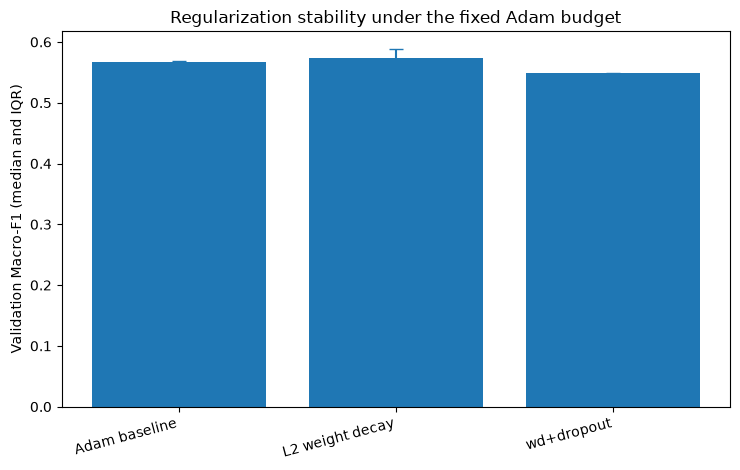

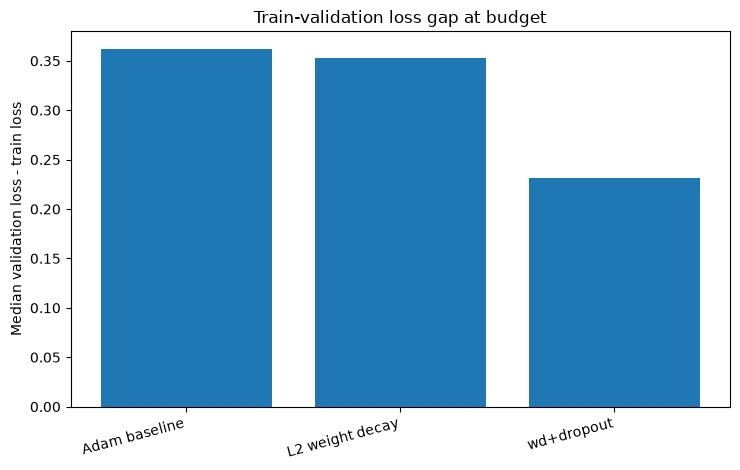

In [13]:
plot_summary = pd.concat([
    single_summary[single_summary.condition.isin(["Adam baseline", best_single])],
    combo_summary,
], ignore_index=True)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
grouped = plot_summary.groupby("condition").best_val_macro_f1
labels = list(grouped.groups)
meds = grouped.median().reindex(labels)
q1 = grouped.quantile(.25).reindex(labels); q3 = grouped.quantile(.75).reindex(labels)
ax.bar(range(len(labels)), meds.values)
ax.errorbar(range(len(labels)), meds.values, yerr=[meds.values-q1.values, q3.values-meds.values], fmt="none", capsize=5)
ax.set_xticks(range(len(labels)), labels, rotation=15, ha="right")
ax.set_ylabel("Validation Macro-F1 (median and IQR)")
ax.set_title("Regularization stability under the fixed Adam budget")
fig.tight_layout(); fig.savefig(FIG_DIR / "regularization_stability_summary.png", dpi=160, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.8))
gaps = plot_summary.groupby("condition").train_val_loss_gap.median()
ax.bar(range(len(gaps)), gaps.values)
ax.set_xticks(range(len(gaps)), gaps.index, rotation=15, ha="right")
ax.set_ylabel("Median validation loss - train loss")
ax.set_title("Train-validation loss gap at budget")
fig.tight_layout(); fig.savefig(FIG_DIR / "regularization_generalization_gap.png", dpi=160, bbox_inches="tight"); plt.show()

### 13. Lock regularization recipe, then final test evaluation

,method,seed,best_val_loss,best_val_macro_f1,test_accuracy,test_macro_f1,test_balanced_accuracy,wall_time_sec,gradient_evaluations,function_evaluations,notes
0,Adam baseline,42,0.599047,0.566645,0.656366,0.565117,0.743569,4.621267,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
1,Adam baseline,202,0.599413,0.569909,0.675458,0.567106,0.757692,4.332321,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
2,Adam baseline,7641,0.591239,0.564122,0.641106,0.565892,0.746417,4.249198,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
3,Best single: L2 weight decay,42,0.595441,0.602377,0.679251,0.585650,0.744786,4.354039,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
4,Best single: L2 weight decay,202,0.593462,0.552304,0.659888,0.560366,0.753859,4.336246,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
5,Best single: L2 weight decay,7641,0.583988,0.573778,0.646635,0.569672,0.745263,4.342379,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
6,Best combination: wd+dropout,42,0.579184,0.549942,0.635796,0.547988,0.749990,4.866383,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
7,Best combination: wd+dropout,202,0.609271,0.542688,0.641115,0.544085,0.751433,4.873247,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
8,Best combination: wd+dropout,7641,0.583323,0.548331,0.647651,0.550109,0.752776,4.825133,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."


,precision,recall,f1-score,support
Cover_Type_1,0.716207,0.689863,0.702788,204548.000000
Cover_Type_2,0.807210,0.601227,0.689156,273549.000000
Cover_Type_3,0.661802,0.683023,0.672245,34523.000000
Cover_Type_4,0.383746,0.806257,0.519995,2653.000000
Cover_Type_5,0.146413,0.861226,0.250277,9166.000000
Cover_Type_6,0.401256,0.632715,0.491079,16769.000000
Cover_Type_7,0.476487,0.930671,0.630281,19804.000000
accuracy,0.656366,0.656366,0.656366,0.656366
macro avg,0.513303,0.743569,0.565117,561012.000000
weighted avg,0.728474,0.656366,0.677116,561012.000000


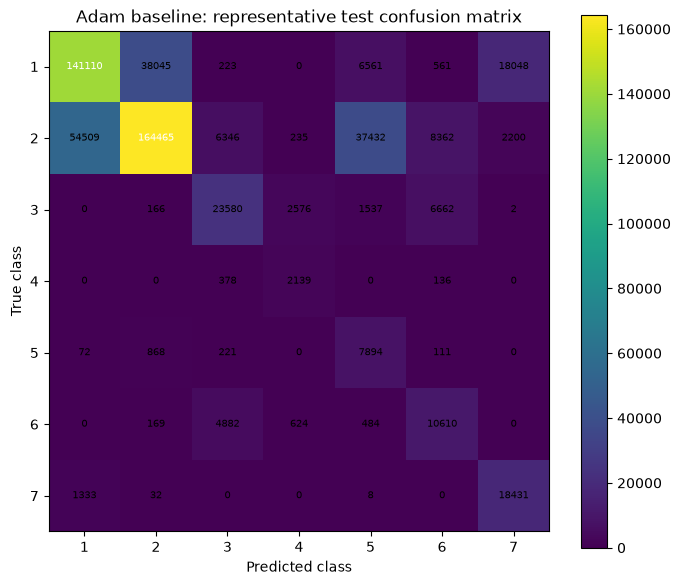

,precision,recall,f1-score,support
Cover_Type_1,0.673011,0.765444,0.716258,204548.000000
Cover_Type_2,0.848055,0.526286,0.649503,273549.000000
Cover_Type_3,0.685899,0.630507,0.657038,34523.000000
Cover_Type_4,0.428719,0.783264,0.554133,2653.000000
Cover_Type_5,0.144084,0.855008,0.246609,9166.000000
Cover_Type_6,0.383069,0.741010,0.505050,16769.000000
Cover_Type_7,0.514972,0.915320,0.659116,19804.000000
accuracy,0.646635,0.646635,0.646635,0.646635
macro avg,0.525401,0.745263,0.569672,561012.000000
weighted avg,0.735113,0.646635,0.663294,561012.000000


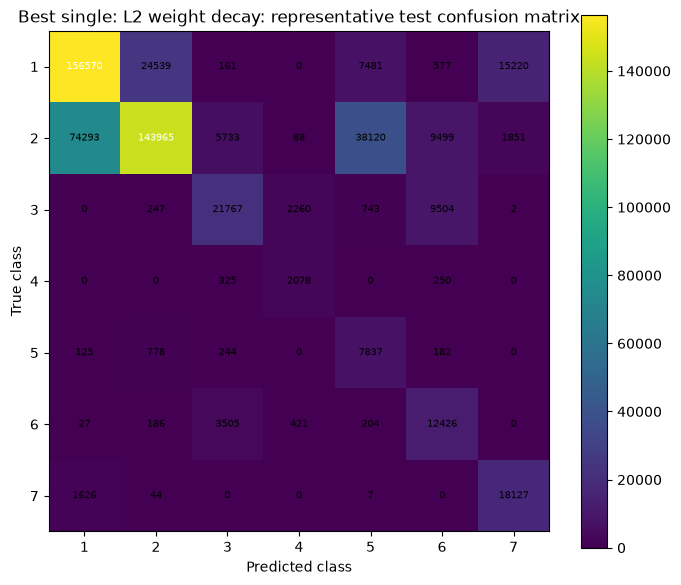

,precision,recall,f1-score,support
Cover_Type_1,0.722443,0.681982,0.701630,204548.000000
Cover_Type_2,0.801610,0.593912,0.682305,273549.000000
Cover_Type_3,0.667627,0.597254,0.630483,34523.000000
Cover_Type_4,0.316456,0.876366,0.465000,2653.000000
Cover_Type_5,0.140553,0.872573,0.242107,9166.000000
Cover_Type_6,0.379227,0.720914,0.497009,16769.000000
Cover_Type_7,0.479848,0.926429,0.632230,19804.000000
accuracy,0.647651,0.647651,0.647651,0.647651
macro avg,0.501109,0.752776,0.550109,561012.000000
weighted avg,0.727422,0.647651,0.670636,561012.000000


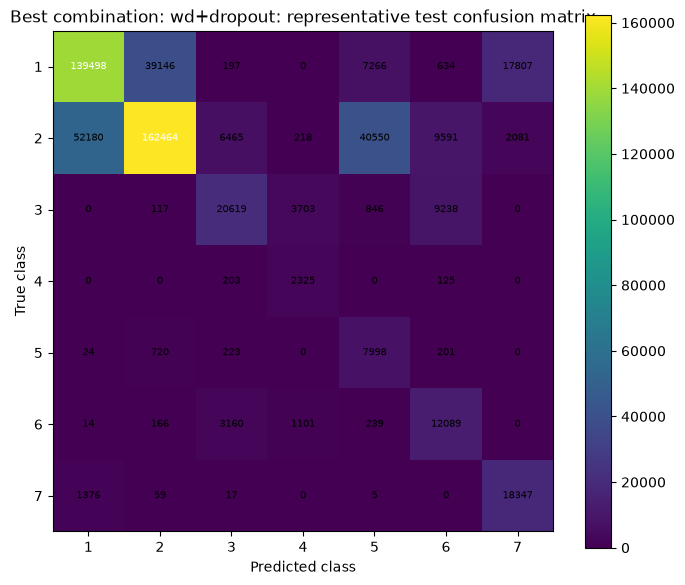

In [14]:
best_combo_cfg = make_combo(best_combo_name)
best_regularization_config = {
    "name": best_combo_name,
    "weight_decay": best_combo_cfg.weight_decay,
    "dropout": best_combo_cfg.dropout,
    "label_smoothing": best_combo_cfg.label_smoothing,
    "input_noise_std": best_combo_cfg.input_noise_std,
    "early_stopping_patience": best_combo_cfg.early_stopping_patience,
    "optimizer": {"name": "adam", "lr": ADAM_LR, "beta1": ADAM_BETA1, "beta2": ADAM_BETA2},
    "batch_size": SL_BATCH_SIZE,
    "max_updates": MAIN_UPDATES,
    "best_single_regularizer": best_single,
    "best_single_value": float(BEST_VALUE[best_single]),
    "selection_rule": "median validation Macro-F1; validation loss tie-break",
}
save_json(RESULTS_DIR / "best_regularization_config.json", best_regularization_config)

locked = {
    "Adam baseline": {seed: single_runs[("Adam baseline", seed)] for seed in SEEDS},
    f"Best single: {best_single}": {seed: single_runs[(best_single, seed)] for seed in SEEDS},
    f"Best combination: {best_combo_name}": {seed: combo_runs[(best_combo_name, seed)] for seed in SEEDS},
}

final_rows, reports, cms = [], {}, {}
if not SMOKE_TEST:
    for label, seed_runs in locked.items():
        for seed, run in seed_runs.items():
            row, report, cm, _ = evaluate_test_locked(run, label)
            final_rows.append(row); reports[(label, seed)] = report; cms[(label, seed)] = cm
    final_metric_table = pd.DataFrame(final_rows)
    final_metric_table.to_csv(RESULTS_DIR / "final_metric_table.csv", index=False)
    display(final_metric_table)

    for label in locked:
        rep_seed = representative_seed(final_metric_table[final_metric_table.method.eq(label)])
        reports[(label, rep_seed)].to_csv(RESULTS_DIR / f"classification_report_{label.split(':')[0].replace(' ','_')}.csv")
        cms[(label, rep_seed)].to_csv(RESULTS_DIR / f"confusion_matrix_{label.split(':')[0].replace(' ','_')}.csv")
        display(reports[(label, rep_seed)])
        plot_confusion_matrix(cms[(label, rep_seed)], f"{label}: representative test confusion matrix",
                              FIG_DIR / f"confusion_matrix_{label.split(':')[0].replace(' ','_')}.png")
else:
    print("Smoke test mode: final held-out test evaluation intentionally skipped.")